In [17]:
#This is using Jakub's version of likety fit
import k3d
import sys
sys.path.append("/eos/user/v/vgousyle/proton_search/Geometry/")
from Geometry.Device import Device
#sys.path.insert(0, "../../LicketyFit")
#Have to insert absolute path for all the tables path in the emitter and different files
from LicketyFit.Emitter import Emitter
from LicketyFit.Event import SimulatedEvent

from LicketyFit.Event import *
from LicketyFit.PMT import *
from LicketyFit.MarkovChain import *
from LicketyFit.Emitter import *

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import uproot, json, awkward as ak
sys.path.append("/eos/user/v/vgousyle/LicketyFit2_tests/work_dir")
from read_sim_data import *

plt.style.use('dark_background')

In [ ]:
#Proton initial conditions from what we know
#0.51,105.66,139,938.28,2808.39,3727.38,6533
mass = np.array([105.66,105.66,938.28])#Muon,pion, proton
p=np.array([320,770,1500]) #For proton
E = np.sqrt(p**2 + mass**2)
beta = p / E  # v/c
print(beta)
#Calculate initial Cerenkov angle 
theta_c = np.arccos(1./(1.33*beta)) * 180/np.pi
print(theta_c)
#Track lenght is 700mm -> 800 for 1.3GeV from paper ! 



[0.94957565 0.99071613 0.84780011]
[37.6453931  40.63043964 27.51875461]


In [72]:
with open('/eos/user/v/vgousyle/LicketyFit2_tests/work_dir/estimates_300MeV_batches_all_3.dict','rb') as f:
    est_dict = pickle.load(f)

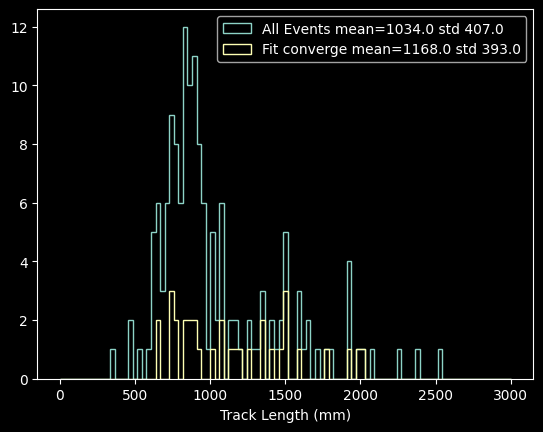

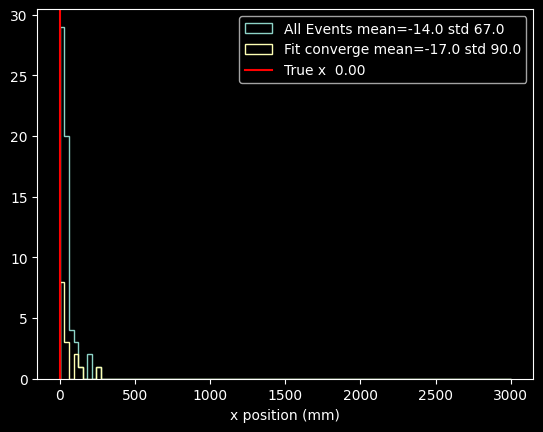

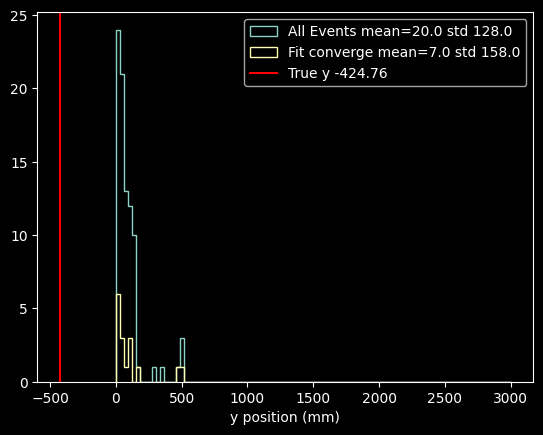

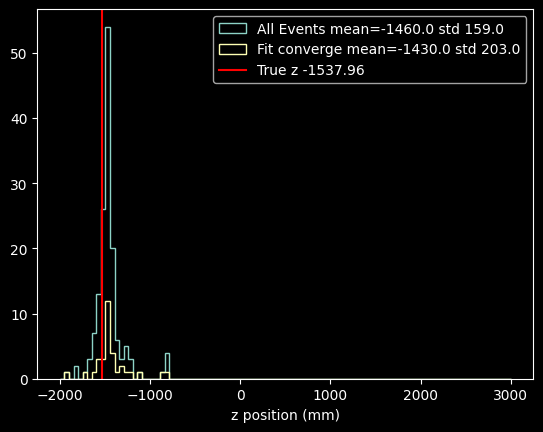

In [73]:
good=np.where(est_dict['minimum_found'])

true_x=0
true_y=-42.47625*10
true_z=-153.7963*10

plt.hist(np.array(est_dict['length']),histtype='step',bins=np.linspace(0,3000,100),label="All Events mean="+str(np.round(np.mean(est_dict['length'])))+" std "+str(np.round(np.std(est_dict['length']))))
plt.hist(np.array(est_dict['length'])[good],histtype='step',bins=np.linspace(0,3000,100),label="Fit converge mean="+str(np.round(np.mean(np.array(est_dict['length'])[good])))+" std "+str(np.round(np.std(np.array(est_dict['length'])[good]))))
plt.legend()
plt.xlabel('Track Length (mm)')
plt.show()
plt.hist(np.array(est_dict['x']),histtype='step',bins=np.linspace(0,3000,100),label="All Events mean="+str(np.round(np.mean(est_dict['x'])))+" std "+str(np.round(np.std(est_dict['x']))))
plt.hist(np.array(est_dict['x'])[good],histtype='step',bins=np.linspace(0,3000,100),label="Fit converge mean="+str(np.round(np.mean(np.array(est_dict['x'])[good])))+" std "+str(np.round(np.std(np.array(est_dict['x'])[good]))))

plt.axvline(true_x,color='r',label="True x  {:2.2f}".format(true_x))
plt.xlabel('x position (mm)')
plt.legend()
plt.show()
plt.hist(np.array(est_dict['y']),histtype='step',bins=np.linspace(0,3000,100),label="All Events mean="+str(np.round(np.mean(est_dict['y'])))+" std "+str(np.round(np.std(est_dict['y']))))
plt.hist(np.array(est_dict['y'])[good],histtype='step',bins=np.linspace(0,3000,100),label="Fit converge mean="+str(np.round(np.mean(np.array(est_dict['y'])[good])))+" std "+str(np.round(np.std(np.array(est_dict['y'])[good]))))

plt.axvline(true_y,color='r',label="True y {:2.2f}".format(true_y))
plt.xlabel('y position (mm)')
plt.legend()
plt.show()
plt.hist(np.array(est_dict['z']),histtype='step',bins=np.linspace(-2000,3000,100),label="All Events mean="+str(np.round(np.mean(est_dict['z'])))+" std "+str(np.round(np.std(est_dict['z']))))
plt.hist(np.array(est_dict['z'])[good],histtype='step',bins=np.linspace(-2000,3000,100),label="Fit converge mean="+str(np.round(np.mean(np.array(est_dict['z'])[good])))+" std "+str(np.round(np.std(np.array(est_dict['z'])[good]))))
plt.axvline(true_z,color='r',label="True z {:2.2f}".format(true_z))
plt.legend()
plt.xlabel('z position (mm)')
plt.show()

In [39]:
est_dict['length']

[1687.6415227274606,
 793.4310772855927,
 924.076397504878,
 947.3361143566731,
 830.5432655579565,
 737.1795334866332,
 1333.8771217600308,
 761.0131331893406,
 1317.8241874991127,
 835.8156348492812,
 1903.9388144376203,
 1089.497302121949,
 905.9151723871751,
 1006.5339688758793,
 499.9380080398997,
 790.0745207811993,
 499.81846800990024,
 499.9180218136645,
 815.5069895592562,
 988.1609242732142,
 617.4325224982797,
 1010.6814971122961,
 892.1762804630214,
 2989.061569339718,
 507.81201472182886,
 700.7246920189558,
 924.0086904272639,
 1046.2167399188206,
 749.1152473122421,
 499.9946668997017,
 681.2868614128685,
 522.3228238721456,
 816.6614019662627,
 828.4409380501451,
 752.5592177434071,
 556.2308335883642,
 2274.3376769491247,
 499.3725212948757,
 784.88098769542,
 741.7159076454968,
 2258.5250303693915,
 670.8559289867885,
 836.7567819872052,
 1449.0595635926095,
 901.9596218500827,
 499.04877040254564,
 1040.3067744170596,
 789.5024192302606,
 1022.2229569509766,
 779.702

In [ ]:
hall = Device.open_file('/eos/user/v/vgousyle/proton_search/Geometry/examples/wcte_bldg157.geo')
wcte = hall.wcds[0]
n_mpmt = len(wcte.mpmts)

# Create an empty simulated event
simulated_event = SimulatedEvent(run_number=1, serial_number=1, n_mpmt=n_mpmt)

# Turn on only the good mPMTs and their PMTs
good_mpmt_slot_ids = [0,2,4,6,8,10,11,13,21,22,23,25,28,29,30,31,34,35,36,37,38,39,40,41,43,44,47,50,51,52,53,54,56,58,
                      60,61,62,64,66,68,69,70,71,73,75,81,82,83,84,86,87,89,93,95,101,103,104]

bad_pmts = {
    66: [4, 5, 12, 13, 18],   # mPMT slot ID 66 has bad PMTs at these positions
    84: [6]                   # mPMT slot ID 84 has bad PMT at position 6
}
#Setting a flag on the mPMT 
for i_mpmt in range(n_mpmt):
    if wcte.mpmts[i_mpmt] is None :#or i_mpmt not in good_mpmt_slot_ids:
        continue
    simulated_event.mpmt_status[i_mpmt] = True
    for i_pmt in range(simulated_event.npmt_per_mpmt):
        if wcte.mpmts[i_mpmt].pmts[i_pmt] is None:
            continue
        #if i_mpmt in bad_pmts and i_pmt in bad_pmts[i_mpmt]:
        #    continue
        simulated_event.pmt_status[i_mpmt][i_pmt] = True

IndentationError: unexpected indent (3666675608.py, line 2)

In [ ]:
#Light calculation
emitter = Emitter(starting_time, start_coord, direction, beta, length, intensity)
# Simulate the emission and record hits in the simulated event
costs, mean_pes = emitter.emit(simulated_event, wcte, place_info='design')

In [ ]:
count_pmt = 0
count_hit_pmt = 0
mpmts_hit = []
hit_times = []
pe_sum = 0
max_pe = -1
for i_mpmt in range(n_mpmt):
    if simulated_event.mpmt_status[i_mpmt]:
        for i_pmt in range(simulated_event.npmt_per_mpmt):
            if simulated_event.pmt_status[i_mpmt][i_pmt]:
                count_pmt += 1
                if len(simulated_event.expected_hit_pe[i_mpmt][i_pmt]) > 0:
                    count_hit_pmt += 1
                    if i_mpmt not in mpmts_hit:
                        mpmts_hit.append(i_mpmt)
                for hit_pe in simulated_event.expected_hit_pe[i_mpmt][i_pmt]:
                    pe_sum += hit_pe
                    max_pe = max(max_pe, hit_pe)
                for hit_time in simulated_event.expected_hit_times[i_mpmt][i_pmt]:
                    hit_times.append(hit_time)


print(f'Number of PMTs: {count_pmt}, Number of hit PMTs: {count_hit_pmt}, Total PE: {pe_sum}')
print(f'{len(mpmts_hit)} mPMTs hit: {mpmts_hit}')
print(f'Mean hit time: {np.mean(hit_times):.2f} ns, RMS hit time: {np.std(hit_times):.2f} ns')
print(f'Max PE on a single PMT: {max_pe:.2f}')

In [ ]:
# show 1D distribution of cost (the incident angle) and mean PE
costs = np.array(costs)
mean_pes = np.array(mean_pes)
plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.hist(costs, bins=50, range=(0,1.), color='cyan', lw=2)
plt.xlabel('Cost (cosine of incident angle)')
plt.ylabel('Number of PMTs')
plt.title('Distribution of cos(theta) (cosine of incident angle)')
plt.grid()
plt.subplot(2,1,2)
plt.hist(mean_pes, bins=60, range=(0.,6.), color='magenta', lw=2)
plt.xlabel('Mean expected PE')
plt.ylabel('Number of PMTs')
plt.title('Distribution of mean expected PE')
plt.grid()
plt.tight_layout()
#plt.savefig('wcte_cost_pe.png')
plt.show()

# Show 2D distribution of cost (the incident angle) and mean PE
plt.figure(figsize=(8,6))
plt.hist2d(costs, mean_pes, bins=(50,50), range=((0,1.),(0.,6.)), cmap='plasma')
plt.colorbar(label='Number of PMTs')
plt.xlabel('Cost (cosine of incident angle)')
plt.ylabel('Mean expected PE')
plt.title('2D Distribution of cos(theta) and mean expected PE')
plt.grid()
#plt.savefig('wcte_cost_vs_pe.png')
plt.show()

In [ ]:
single_pe_amp_mean = 60.
single_pe_amp_std = 20.
single_pe_time_std = 1.
separation_time = 40.
amp_threshold = 20.
noise_rate = 0.
pmt = PMT(single_pe_amp_mean, single_pe_amp_std, single_pe_time_std, separation_time, amp_threshold, noise_rate)

pmt_model = PMT(single_pe_amp_mean,
                single_pe_amp_std,
                single_pe_time_std,
                separation_time,
                amp_threshold,
                noise_rate)

#pmt.add_noise(simulated_event)
#pmt.apply_response(simulated_event)
# Show a distribution of hit charges

hit_charges = []
for i_mpmt in range(n_mpmt):
    if simulated_event.mpmt_status[i_mpmt]:
        for i_pmt in range(simulated_event.npmt_per_mpmt):
            if simulated_event.pmt_status[i_mpmt][i_pmt]:
                for charge in simulated_event.hit_charges[i_mpmt][i_pmt]:
                    hit_charges.append(charge)
plt.figure(figsize=(8,6))
plt.hist(hit_charges, bins=100, range=(0.,500.), color='orange', lw=2)
plt.xlabel('Hit charge (ADC counts)')
plt.ylabel('Number of hits')
plt.title('Distribution of hit charges after electronics response')
plt.grid()
#plt.savefig('wcte_hit_charges.png')

In [ ]:
#initial guess (it will be varied by MCMC)
#Example used in the past 
"""
starting_time = 5.
start_coord = (20., 15., -1200.)
cxy = 0.01
direction = (cxy, cxy, np.sqrt(1.-2*cxy**2))
beta = 0.9999
length = 800.
intensity = 15. 
"""
init_E_vs_dist_travelled = np.load('../tables/init_E_vs_dist_travelled.npy')
dist_travelled = init_E_vs_dist_travelled[:,0]
init_energy = init_E_vs_dist_travelled[:,1]

length_guess = np.interp(300,init_energy,dist_travelled*10)
starting_time_guess = 0
start_coord_guess   = (0.0, 0, -1000)   # mm
direction_guess     = (0.0, 0.0, 1.0)   # along +z
beta_guess          = 0.96
length_guess        = length_guess          # mm
intensity_guess     = 10.0               # PE at 1 m, normal incidence

emitter_model = Emitter(starting_time_guess,
                        start_coord_guess,
                        direction_guess,
                        beta_guess,
                        length_guess,
                        intensity_guess)

In [ ]:
corr_pos = None
emitter_copy = emitter_model.copy()
p_locations, direction_zs = emitter_copy.get_pmt_placements(ev, wcte, 'design')
init_KE = np.interp(length_guess, dist_travelled*10, init_energy) # Convert distance to mm
ss = emitter_copy.get_emission_points(p_locations,init_KE)
exp_pes, exp_ts = emitter_copy.get_expected_pes_ts(wcte, ss, p_locations, direction_zs,corr_pos,obs_pes)

In [ ]:
corr_pos = {'wut':np.array([]),'delam':np.array([])}
corr_pos = None
def get_neg_log_likelihood_npe_t(x0, y0, z0, cx, cy, length, t0):
    # build direction unit vector
    cz = np.sqrt(1.0 - cx**2 - cy**2)
    direction = (cx, cy, cz)
    start_coord = (x0, y0, z0)
    
    #emitter_copy.intensity = intensity
    # update emitter model
    emitter_copy.start_coord   = start_coord
    emitter_copy.starting_time = t0
    emitter_copy.direction     = direction
    emitter_copy.length        = length

    init_KE = np.interp(length, dist_travelled*10, init_energy) # Convert distance to mm
    # expected number of PE and times at each PMT
    ss = emitter_copy.get_emission_points(p_locations,init_KE)
    #print(ss[0])
    #print('')
    exp_pes, exp_ts = emitter_copy.get_expected_pes_ts(wcte, ss, p_locations, direction_zs,corr_pos,obs_pes)
    #print(np.mean(exp_pes))
    
    #pe_scaling_factor = np.mean(obs_pes)/np.mean(exp_pes)
    
    #exp_pes = np.array(exp_pes)*pe_scaling_factor
    
    
   
    #print(np.mean(exp_pes))
    # compare to observed data using the PMT-likelihood model
    neg_ll = pmt_model.get_neg_log_likelihood_npe_t(exp_pes, obs_pes, exp_ts, obs_ts)
    
    return float(neg_ll)


In [ ]:
from minuit_fit import *

x0_init = 0
y0_init = 0
z0_init = -800
cx_init = 0.0
cy_init = 0.0
length_init = 500
t0_init = 0

m = Minuit(
        get_neg_log_likelihood_npe_t,
        x0=x0_init,
        y0=y0_init,
        z0=z0_init,
        cx=cx_init,
        cy=cy_init,
        length=length_init,
        t0=t0_init
    )

m.limits["x0"] = (-2000, 2000)
m.limits["y0"] = (-2000, 2000)
m.limits["z0"] = (-2000, 2000)
m.limits["cx"] = (-0.5, 0.5)
m.limits["cy"] = (-0.5, 0.5)
m.limits["length"] = (0, 3000)   
m.limits["t0"] = (-10, 10)
#m.limits["intensity"] = (0,30)

m.errors["x0"] = 20.0
m.errors["y0"] = 20.0
m.errors["z0"] = 20.0
m.errors["cx"] = 0.01
m.errors["cy"] = 0.01
m.errors["length"] = 50.0
m.errors["t0"] = 0.5

In [ ]:
#Run the actual thing
m.errordef = Minuit.LIKELIHOOD
m.strategy = 1  # more careful

#m.simplex()
m.migrad(ncall=3000)

In [ ]:
#Basic test
init_E_vs_dist_travelled = np.load('../tables/init_E_vs_dist_travelled.npy')
dist_travelled = init_E_vs_dist_travelled[:,0]
init_energy = init_E_vs_dist_travelled[:,1]

length_t = np.interp(300,init_energy,dist_travelled*10)

x_t= 0
y_t = 0
z_t = -1000
cx_t = 0
cy_t = 0
#length_t = 1700
t_t = 0.

print("True FCN:", get_neg_log_likelihood_npe_t(
    x_t, y_t, z_t, cx_t, cy_t, length_t, t_t
))